In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')

peng = pd.read_csv("penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)
bike = pd.read_csv("bike-sharing-daily.csv", parse_dates=["dteday"])


In [9]:
a = smf.ols("body_mass_g ~ flipper_length_mm", data=peng).fit()
b = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm", data=peng).fit()
c = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm", data=peng).fit()

models = [a,b,c]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "RSE":[np.sqrt(m.scale) for m in models],
    "F":[m.fvalue for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["A: flipper", "B: + bill_depth", "C: + bill_length"]).round(4))
print(sm.stats.anova_lm(a,b,c))
print(c.pvalues.round(4))
X =c.model.exog
for i, name in enumerate(c.model.exog_names):
    if name != "Intercept":
        print("VIF", name, round(variance_inflation_factor(X, i), 2))

print(peng[["flipper_length_mm", "bill_depth_mm", "bill_length_mm"]].corr().round(2))

                      R2  adj_R2       RSE          F        AIC        BIC
A: flipper        0.7590  0.7583  394.2782  1070.7446  5060.8549  5068.5245
B: + bill_depth   0.7610  0.7596  393.1784   539.8239  5059.9369  5071.4413
C: + bill_length  0.7615  0.7594  393.4048   359.6718  5061.3203  5076.6596
   df_resid           ssr  df_diff        ss_diff         F    Pr(>F)
0     340.0  5.285480e+07      0.0            NaN       NaN       NaN
1     339.0  5.240575e+07      1.0  449043.646743  2.901411  0.089419
2     338.0  5.231136e+07      1.0   94393.101155  0.609903  0.435371
Intercept            0.0000
flipper_length_mm    0.0000
bill_depth_mm        0.1441
bill_length_mm       0.4354
dtype: float64
VIF flipper_length_mm 2.67
VIF bill_depth_mm 1.61
VIF bill_length_mm 1.87
                   flipper_length_mm  bill_depth_mm  bill_length_mm
flipper_length_mm               1.00          -0.58            0.66
bill_depth_mm                  -0.58           1.00           -0.24
bill_length

Q1
r2 only goes up when predictors are added and the f-statistic tests whether any of those predictors matter so when it shrinks, that means its a weak predictor but doesnt help in identifying which specific predictor helped the results. The nested f test shows that adding bill depth to flipper only gets us F of 2.90 and p of 0.089 and adding length gives an F of 0.61 and p or 0.435, so none of them actually improve the fit. The coefficient t test shows that none of the variables are significant once the flipper length is added. the AIC is values are basically all very similar and the BIC has the lowest value for the flipper model. the VIF values are all under 3 so we know that multicollinearity doesnnt make any of the variables insignificant and both bill variables are correlated with the flipper length. All of this combined shows that the flipper only model is the model that most of the tests support. This is different from my answer from last week which was the second model, and this might be because the r2 and adj r2 tend to lean towards models with two predictors.


             cnt   temp    hum  windspeed
cnt        1.000  0.627 -0.101     -0.235
temp       0.627  1.000  0.127     -0.158
hum       -0.101  0.127  1.000     -0.248
windspeed -0.235 -0.158 -0.248      1.000


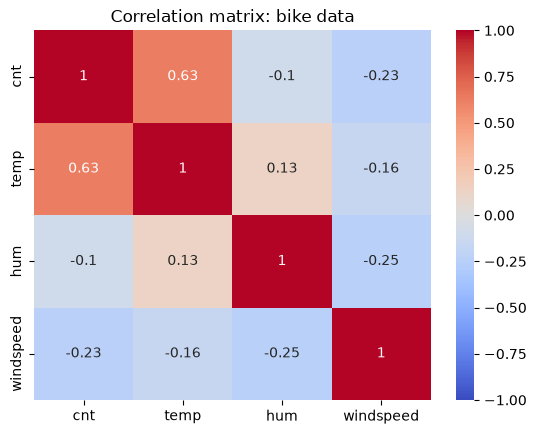

In [10]:
corr = bike[["cnt", "temp", "hum", "windspeed"]].corr()
print(corr.round(3))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: bike data")
plt.show()

In [11]:
b3 = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()
print(b3.summary())

X = b3.model.exog
for i, name in enumerate(b3.model.exog_names):
    if name != "Intercept":
        print("VIF", name, round(variance_inflation_factor(X, i), 3))

print("Durbin-Watson:", round(sm.stats.durbin_watson(b3.resid), 2))

print(b3.params[["temp", "hum", "windspeed"]] * 0.1)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        16:20:47   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.0

b. the vifs are 1.03 for temp, 1.08 for windspeed and 1.07 for humidity. temp had 6626 rentals per unit and when its normalized it shows that 0.1 is ~4.7C so there are more rentals when its warmer. humidity shows -3100 per unit so humid days mead less rentals. windspeed is at -4807 so windy days also mean less rentals. This tracks because people want to ride bikes in warm and calm, nice weather, 

In [ ]:
#c
c1 = smf.ols("cnt ~ temp", data=bike).fit()
c2 = smf.ols("cnt ~ temp + hum", data=bike).fit()
c3 = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()

print(sm.stats.anova_lm(c1, c2, c3))

models = [c1, c2, c3]
print(pd.DataFrame({
    "R2":[m.rsquared for m in models],
    "adj_R2":[m.rsquared_adj for m in models],
    "AIC":[m.aic for m in models],
    "BIC":[m.bic for m in models],
}, index=["1: temp", "2: temp + hum", "3: temp + hum + windspeed"]).round(4))

   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     729.0  1.660847e+09      0.0           NaN        NaN           NaN
1     728.0  1.570304e+09      1.0  9.054330e+07  44.569779  4.869005e-11
2     727.0  1.476897e+09      1.0  9.340630e+07  45.979085  2.475445e-11
                               R2  adj_R2         AIC         BIC
1: temp                    0.3937  0.3929  12777.5357  12786.7245
2: temp + hum              0.4268  0.4252  12738.5568  12752.3400
3: temp + hum + windspeed  0.4609  0.4587  12695.7278  12714.1055


d. I would pick the third model because hum+temp gives an f of 44.6 and p of 4.87e-11 and adding wind on top gives f of 46 and p of 2.48e-11 so everything is significant. the adj r2 increases and aic and bic decrease after each predictor and because the vifs are at about 1 for all if them, the extra predictors dont do anything. So model 3 is the best out of all of them in my opinion.